# Resumen: Calidad del dato

La calidad del dataset es **alta**, con una tasa de retención superior al **99%**, reflejando que la extracción ya era fiable.

---

## 1. Variables transversales
- **Errores:** Casos inválidos mínimos y ya depurados sin impacto relevante.  
- **Nulos:** Concentrados en variables de *reviews* (interpretables como ausencia de reseñas). El resto (<1%) permite imputaciones simples.  
- **Outliers:** Menos del 20%; representan la realidad del mercado → no se eliminan.  
- **Categóricas:** Limpias y estandarizadas
---

## 2. Dimensión Temporal
- Cobertura completa diaria, sin valores faltantes.  
- Alta variabilidad en el volumen de registros diarios.  
---

## 3. Dimensión Espacial
- ~4.35M registros geolocalizados válidos.  
- Efecto borde reducido (~2.5%).  
- Sin impacto significativo del MAUP: los barrios son una unidad de agregación fiable.

# 0. Conexión con proyecto e importación de dataset

In [1]:
# %pip install contextily

In [2]:
import pandas as pd
import geopandas as gpd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
warnings.filterwarnings('ignore')

In [3]:
from google.cloud import bigquery
client = bigquery.Client(project="project3grupo1")

In [4]:
query = """
SELECT *
FROM `project3grupo1.dbt_transform.mart_occupancy_features`
"""

df_raw = client.query(query).to_dataframe()

# 1. Calidad del dato variables transversales

## 1.1 Clase validación de valores - tratamiento de valores erróneos variables continuas

formato se da por válido tras la ingesta

In [5]:
class BaseQualityValidator:
    """
    Validador de calidad tabular base guiado por reglas lógicas
    """
    def __init__(self):
        # Diccionario de reglas: 'columna'-> (min, max)

        #temporalidad
        self.valid_ranges = { 'is_occupied': (0, 1),
            'day_of_week': (1, 7),
            'month': (1, 12),
            'is_weekend': (0, 1),
            'days_to_next_holiday': (0, 365),

            # alojamiento
            'accommodates': (1, 50),
            'bedrooms': (0, 20),
            'beds': (0, 50),
            'listing_price': (1, 50000),
            'minimum_nights': (1, 365),

            # Reviews (escala 0 a 5)
            'review_scores_rating': (0.0, 5.0),
            'review_scores_cleanliness': (0.0, 5.0),
            'review_scores_location': (0.0, 5.0),
            'review_scores_value': (0.0, 5.0),

            # Meteorología
            'temp_max': (-20.0, 55.0),
            'temp_min': (-30.0, 45.0),
            'temp_mean': (-25.0, 50.0),
            'precipitation_mm': (0.0, 500.0),

            # Eventos y festivos
            'is_holiday': (0, 1),
            'num_events': (0, 999),
            'num_concerts': (0, 999),
            'num_sports': (0, 999),
            'num_festivals': (0, 999),
            'max_attendance': (0, 1000000),
            'total_attendance': (0, 2000000) }

    def drop_critical_nulls(self, df: pd.DataFrame) -> pd.DataFrame:
        """Elimina filas donde target o ID son nulas o inválidas."""

        initial_len = len(df)
        df_clean = df.dropna(subset=['is_occupied'])
        df_clean = df_clean.dropna(subset=['listing_id'])
        df_clean = df_clean[df_clean['listing_id'] > 0]

        dropped = initial_len - len(df_clean)

        if dropped > 0:
            print(f"[-] Eliminadas {dropped} filas por nulos críticos ('is_occupied' o 'listing_id' inválido).")
        return df_clean

    def drop_invalid_value_range(self, df: pd.DataFrame, col: str, min_val: float, max_val: float) -> pd.DataFrame:
        """Filtra filas fuera del rango [min_val, max_val]. Mantiene los nulos."""
        if col not in df.columns:
            return df

        initial_len = len(df)
        valid_mask = df[col].isna() | df[col].between(min_val, max_val)
        df_clean = df[valid_mask]
        dropped = initial_len - len(df_clean)

        if dropped > 0:
            print(f"[-] Eliminadas {dropped} filas con '{col}' fuera de rango [{min_val}, {max_val}].")
        return df_clean

    def run_all(self, df: pd.DataFrame) -> pd.DataFrame:
        df_clean = df.copy()
        df_clean = self.drop_critical_nulls(df_clean)

        for col, (min_v, max_v) in self.valid_ranges.items():
            df_clean = self.drop_invalid_value_range(df_clean, col, min_v, max_v)

        print("-" * 55)
        print(f"[+] Validación completada.")
        print(f"    Filas originales: {len(df)}")
        print(f"    Filas retenidas:  {len(df_clean)}")
        print(f"    Tasa de retención: {(len(df_clean)/len(df))*100:.2f}%\n")

        return df_clean

In [6]:
base_validator = BaseQualityValidator()

## 1.2 Clase identificadora de nulos y outliers variables continuas

In [7]:
class TabularNullOutliers:
    """ Identifica nulos y outliers (IQR) en las variables tabulares transversales"""

    def __init__(self):
        # Variables continuas
        self.continuous_cols = [
            'accommodates', 'bedrooms', 'beds', 'listing_price', 'minimum_nights',
            'review_scores_rating', 'review_scores_cleanliness',
            'review_scores_location', 'review_scores_value',
            'temp_max', 'temp_min', 'temp_mean', 'precipitation_mm']

    def report_missing_values(self, df: pd.DataFrame):
        """Genera un reporte de los valores nulos absolutos y relativos por columna."""
        print("\n" + "="*50)
        print("VALORES NULOS")
        print("="*50)

        total_rows = len(df)
        null_counts = df.isnull().sum()
        null_cols = null_counts[null_counts > 0].sort_values(ascending=False)

        if null_cols.empty:
            print("[+] No se encontraron valores nulos en el dataset.")
            return

        report_data = []
        for col, count in null_cols.items():
            percentage = (count / total_rows) * 100
            report_data.append({'Columna': col, 'Nulos': count, 'Porcentaje (%)': round(percentage, 2)})

        report_df = pd.DataFrame(report_data)
        print(report_df.to_string(index=False))
        print("-" * 50)

    def report_iqr_outliers(self, df: pd.DataFrame):
        """
        Calcula y reporta la cantidad de outliers usando el método IQR
        (Interquartile Range: Q1 - 1.5*IQR / Q3 + 1.5*IQR).
        """
        print("\n" + "="*50)
        print("OUTLIERS ESTADÍSTICOS (Método IQR)")
        print("="*50)

        total_rows = len(df)
        outlier_data = []

        for col in self.continuous_cols:
            if col in df.columns:
                # Calculamos Q1, Q3 y el IQR ignorando los nulos
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IQR = Q3 - Q1

                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR

                # Contamos cuántos valores caen fuera de los límites
                outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
                outliers_count = outliers_mask.sum()

                if outliers_count > 0:
                    percentage = (outliers_count / total_rows) * 100
                    outlier_data.append({
                        'Columna': col,
                        'Outliers': outliers_count,
                        '% Outliers': round(percentage, 2),
                        'Límite Inf': round(lower_bound, 2),
                        'Límite Sup': round(upper_bound, 2)})

        if not outlier_data:
            print("[+] No se detectaron outliers según el método IQR.")
        else:
            report_df = pd.DataFrame(outlier_data)
            print(report_df.to_string(index=False))
        print("-" * 50)

    def run_tabular_profiling(self, df: pd.DataFrame):
        """Ejecuta los análisis exploratorios tabulares."""
        self.report_missing_values(df)
        self.report_iqr_outliers(df)

In [8]:
analyzer = TabularNullOutliers()

## 1.3 Clase estandarizadora variables categóricas - sin transformaciones para modelado

In [9]:
class CategoricalQualityValidator:
    """
    Validador de calidad para variables categóricas.
    Se encarga de estandarizar formatos y validar dominios (sin transformaciones)
    """

    def __init__(self):
        # Definimos el dominio esperado para las variables que conocemos
        self.expected_room_types = [
            'Entire home/apt',
            'Private room',
            'Shared room',
            'Hotel room']

        self.valid_bool_strings = ['t', 'f', 'true', 'false', '1', '0']

    def standardize_text_format(self, df: pd.DataFrame, text_cols: list) -> pd.DataFrame:
        """Elimina espacios en blanco accidentales al inicio/final de los strings."""
        df_clean = df.copy()
        for col in text_cols:
            if col in df_clean.columns and df_clean[col].dtype == object:
                # Quitamos espacios y aseguramos que es string
                df_clean[col] = df_clean[col].astype(str).str.strip()
        print(f"[+] Formato de texto estandarizado (strip) en: {text_cols}")
        return df_clean

    def validate_room_type(self, df: pd.DataFrame) -> pd.DataFrame:
        """Elimina registros con tipos de habitación no reconocidos."""
        col = 'room_type'
        if col not in df.columns:
            return df

        initial_len = len(df)
        # Filtramos dejando solo los que están en nuestra lista (o nulos, para no borrarlos aquí)
        valid_mask = df[col].isna() | df[col].isin(self.expected_room_types)
        df_clean = df[valid_mask]

        dropped = initial_len - len(df_clean)
        if dropped > 0:
            print(f"[-] Eliminadas {dropped} filas con '{col}' fuera del dominio esperado.")
        return df_clean

    def standardize_booleans(self, df: pd.DataFrame, col: str = 'instant_bookable') -> pd.DataFrame:
        """
        Unifica el formato de la variable booleana a 1/0 o True/False
        para que sea consistente, eliminando basura tipográfica.
        """
        if col not in df.columns:
            return df

        df_clean = df.copy()
        initial_len = len(df_clean)
        temp_col = df_clean[col].astype(str).str.lower().str.strip()

        valid_mask = temp_col.isna() | temp_col.isin(self.valid_bool_strings)
        df_clean = df_clean[valid_mask]

        mapping = {'t': 1, 'true': 1, '1': 1, 'f': 0, 'false': 0, '0': 0}
        df_clean[col] = temp_col.map(mapping)

        dropped = initial_len - len(df_clean)
        if dropped > 0:
            print(f"[-] Eliminadas {dropped} filas con valores booleanos ilegibles en '{col}'.")
        else:
            print(f"[+] '{col}' estandarizada correctamente a formato 1/0.")

        return df_clean

    def run_all(self, df: pd.DataFrame) -> pd.DataFrame:
        df_clean = df.copy()
        df_clean = self.standardize_text_format(df_clean, ['neighbourhood_cleansed', 'room_type'])
        df_clean = self.validate_room_type(df_clean)
        df_clean = self.standardize_booleans(df_clean, 'instant_bookable')

        print("-" * 50)
        print(f"[+] Validación categórica completada. Filas retenidas: {len(df_clean)}")
        return df_clean

In [10]:
analyzer_cat = CategoricalQualityValidator()

# 2. Validación calidad de la variable temporal

In [11]:
class TemporalQualityValidator:
    """
    Validador de calidad para la dimensión temporal.
    Comprueba la integridad del calendario, rangos lógicos y densidad diaria.
    """

    def __init__(self, date_col: str = 'date'):
        self.date_col = date_col
        self.min_expected_date = pd.to_datetime('2023-01-01')
        self.max_expected_date = pd.to_datetime('2026-12-31')

    def check_nulls_and_format(self, df: pd.DataFrame) -> pd.DataFrame:
        """Asegura que la columna fecha es datetime y no tiene nulos."""
        df_clean = df.copy()
        initial_len = len(df_clean)

        df_clean[self.date_col] = pd.to_datetime(df_clean[self.date_col], errors='coerce')

        df_clean = df_clean.dropna(subset=[self.date_col])

        dropped = initial_len - len(df_clean)
        if dropped > 0:
            print(f"[-] Eliminadas {dropped} filas con fechas nulas o formato inválido.")
        else:
            print(f"[+] Formato temporal validado. 0 nulos detectados en '{self.date_col}'.")

        return df_clean

    def validate_date_range(self, df: pd.DataFrame) -> pd.DataFrame:
        """Filtra fechas que caen fuera de la ventana de estudio esperada."""
        initial_len = len(df)
        valid_mask = df[self.date_col].between(self.min_expected_date, self.max_expected_date)
        df_clean = df[valid_mask]

        dropped = initial_len - len(df_clean)
        if dropped > 0:
            print(f"[-] Eliminadas {dropped} filas fuera del rango temporal esperado ({self.min_expected_date.date()} a {self.max_expected_date.date()}).")

        return df_clean

    def analyze_calendar_completeness(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Analiza la densidad y granularidad. Identifica si faltan días enteros en la serie.
        """
        print("\n" + "="*50)
        print("REPORTE DE DENSIDAD TEMPORAL")
        print("="*50)

        daily_counts = df.groupby(self.date_col).size().rename('num_registros')

        actual_min = daily_counts.index.min()
        actual_max = daily_counts.index.max()

        perfect_calendar = pd.date_range(start=actual_min, end=actual_max, freq='D')
        missing_days = perfect_calendar.difference(daily_counts.index)

        print(f"Rango de datos: {actual_min.date()} al {actual_max.date()}")
        print(f"Total de días esperados: {len(perfect_calendar)}")
        print(f"Total de días con datos: {len(daily_counts)}")
        print(f"Días faltantes (Huecos): {len(missing_days)}")

        if len(missing_days) > 0:
            print("\nALERTA: Faltan los siguientes días en el dataset:")
            for day in missing_days[:5]:
                print(f"  - {day.date()}")
            if len(missing_days) > 5:
                print(f"  ... y {len(missing_days) - 5} días más.")

        print(f"\nDensidad media: {daily_counts.mean():.0f} registros/día")
        print(f"Desviación est. densidad: {daily_counts.std():.0f}")
        print("-" * 50)

        return df

    def infer_temporal_granularity(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Indica posible granularidad del dataset basándose en la
        diferencia (saltos diarios) más común entre fechas consecutivas.
        """
        unique_dates = df[self.date_col].dropna().sort_values().drop_duplicates()

        if len(unique_dates) < 2:
            print("[-] No hay suficientes fechas distintas para calcular la granularidad.")
            return df

        time_diffs = unique_dates.diff().dropna()

        mode_diff = time_diffs.mode()[0]
        days = mode_diff.days

        if days == 1:
            granularity = "Diaria"
        elif days == 7:
            granularity = "Semanal"
        elif 28 <= days <= 31:
            granularity = "Mensual"
        elif 89 <= days <= 93:
            granularity = "Trimestral"
        elif days in [365, 366]:
            granularity = "Anual"
        else:
            granularity = f"Irregular o Específica ({days} días)"

        print(f"[+] Granularidad detectada: {granularity} (Salto modal: {days} días).")
        return df

    def run_all(self, df: pd.DataFrame) -> pd.DataFrame:
        df_clean = df.copy()

        df_clean = self.check_nulls_and_format(df_clean)
        df_clean = self.validate_date_range(df_clean)
        df_clean = self.infer_temporal_granularity(df_clean)
        df_clean = self.analyze_calendar_completeness(df_clean)

        return df_clean

In [12]:
analyzer_temp = TemporalQualityValidator()

# 3. Validación calidad variable espacial

In [13]:
df_barrios = pd.read_csv("/content/BarcelonaCiutat_Barris.csv")
# https://opendata-ajuntament.barcelona.cat/data/es/dataset/20170706-districtes-barris/resource/b21fa550-56ea-4f4c-9adc-b8009381896e

In [15]:
distritos_gdf = gpd.GeoDataFrame(df_barrios,
    geometry=gpd.GeoSeries.from_wkt(df_barrios['geometria_wgs84'],
    crs="EPSG:4326")).to_crs(epsg=3857) #CRS = sistema de coordenadas

# Normalizar nombres barrios en ambos barrios
distritos_gdf['key'] = distritos_gdf['nom_barri'].str.lower().str.strip()

# Agrupar puntos por nombre barrio
conteo_barrios = df_raw.groupby('neighbourhood_cleansed').size().reset_index(name='count')
conteo_barrios['key'] = conteo_barrios['neighbourhood_cleansed'].str.lower().str.strip()

# Mergeo de barrios bcn con conteo de puntos por nombre barrio
gdf_mapa = distritos_gdf.merge(conteo_barrios, on='key', how='left')

In [16]:
class SpatialQualityValidator:
    """
    Validador y procesador espacial.
    Valida coordenadas, asigna CRS, soluciona el MAUP y mapa coroplético densidad
    """
    def __init__(self, lat_col='latitude', lon_col='longitude'):
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.crs_wgs84 = "EPSG:4326"   # Grados (GPS)
        self.crs_mercator = "EPSG:3857" # Metros (Mapas Web y distancias)

        # BBox amplio de BCN para descarte inicial de locuras GPS
        self.bcn_bbox = {'min_lat': 41.31, 'max_lat': 41.47, 'min_lon': 2.05, 'max_lon': 2.23}

    def validate_and_filter_coordinates(self, df: pd.DataFrame) -> pd.DataFrame:
        """Filtra nulos y puntos fuera del Bounding Box base."""
        df_clean = df.dropna(subset=[self.lat_col, self.lon_col]).copy()

        valid_mask = (
            (df_clean[self.lat_col].between(self.bcn_bbox['min_lat'], self.bcn_bbox['max_lat'])) &
            (df_clean[self.lon_col].between(self.bcn_bbox['min_lon'], self.bcn_bbox['max_lon']))
        )

        df_clean = df_clean[valid_mask]
        print(f"[+] Coordenadas base validadas. Retenidos {len(df_clean)} registros dentro del BBox.")
        return df_clean

    def build_geodataframes(self, df_points: pd.DataFrame, df_polygons: pd.DataFrame):
        """Convierte los DataFrames tabulares en GeoDataFrames con su CRS."""
        # 1. Puntos
        gdf_points = gpd.GeoDataFrame(
            df_points,
            geometry=gpd.points_from_xy(df_points[self.lon_col], df_points[self.lat_col]),
            crs=self.crs_wgs84
        )

        # 2. Polígonos (Barrios)
        gdf_polys = gpd.GeoDataFrame(
            df_polygons,
            geometry=gpd.GeoSeries.from_wkt(df_polygons['geometria_wgs84']),
            crs=self.crs_wgs84
        )

        print("[+] GeoDataFrames construidos (EPSG:4326).")
        return gdf_points, gdf_polys

    def calculate_maup_density(self, gdf_points: gpd.GeoDataFrame, gdf_polys: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
        """Detectar si la elección de frontera seleccionado puede alterar la validez de resultados"""
        # 1. Usar Join Espacial para evitar errores de etiquetas de texto
        gdf_polys = gdf_polys.copy()

        gdf_polys['key_spatial'] = gdf_polys['nom_barri'].str.lower().str.strip()

        joined = gpd.sjoin(gdf_points, gdf_polys[['key_spatial', 'geometry']], how='inner', predicate='within')
        conteo = joined.groupby('key_spatial').size().reset_index(name='count')

        # 2. Merge con polígonos
        gdf_mapa = gdf_polys.merge(conteo, on='key_spatial', how='left')
        gdf_mapa['count'] = gdf_mapa['count'].fillna(0)

        # 3. Área y Densidad
        gdf_mapa_3857 = gdf_mapa.to_crs(self.crs_mercator)
        gdf_mapa['area_km2'] = gdf_mapa_3857.geometry.area / 10**6
        gdf_mapa['densidad_anuncios'] = gdf_mapa['count'] / gdf_mapa['area_km2']

        return gdf_mapa

    def plot_maup_risk(self, gdf_points: gpd.GeoDataFrame):
        """Gráfico que cuantifica el riesgo de MAUP basado en la ubicación."""
        counts = gdf_points['is_border_listing'].value_counts().rename({0: 'Interior (Centro)', 1: 'Frontera (Riesgo MAUP)'})

        plt.figure(figsize=(8, 5))
        sns.barplot(x=counts.index, y=counts.values, palette=['#2ecc71', '#e74c3c'])

        # Añadir porcentaje
        total = counts.sum()
        for i, val in enumerate(counts.values):
            pct = (val / total) * 100
            plt.text(i, val, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

        plt.title("Cuantificación del Riesgo MAUP (Efecto de Borde)")
        plt.ylabel("Número de Anuncios")
        plt.show()

    def flag_edge_effects(self, gdf_points: gpd.GeoDataFrame, gdf_polys: gpd.GeoDataFrame, distance_meters=50) -> gpd.GeoDataFrame:
        """Puntos frontera entre poligonos. Añade variable bool si está o no en frontera"""
        gdf_polys_3857 = gdf_polys.to_crs(self.crs_mercator)
        points_geom_3857 = gdf_points.geometry.to_crs(self.crs_mercator)

        city_boundary = gdf_polys_3857.unary_union.boundary
        border_zone = city_boundary.buffer(distance_meters)

        # Filtra qué puntos están cerca antes de hacer la intersección exacta
        sindex = points_geom_3857.sindex
        possible_matches_index = sindex.query(border_zone, predicate="intersects")

        # 4. Asignar resultados
        gdf_points['is_border_listing'] = 0
        gdf_points.iloc[possible_matches_index, gdf_points.columns.get_loc('is_border_listing')] = 1

        print(f"[+] Edge Effects calculados: {gdf_points['is_border_listing'].sum()} anuncios detectados.")
        return gdf_points


    def plot_spatial_distribution(self, gdf_points: gpd.GeoDataFrame, gdf_mapa: gpd.GeoDataFrame, sample_frac=0.02):
        """Genera el mapa visual combinando la coropleta de densidad (MAUP) y los puntos."""
        mapa_3857 = gdf_mapa.to_crs(self.crs_mercator)

        sample_gdf = gdf_points.sample(frac=sample_frac, random_state=42)
        sample_3857 = sample_gdf.to_crs(self.crs_mercator)

        fig, ax = plt.subplots(figsize=(12, 10))

        mapa_3857.plot(
            column='densidad_anuncios', cmap='OrRd',
            alpha=0.75, legend=True, ax=ax,
            edgecolor='black', linewidth=0.5
        )

        sample_3857.plot(ax=ax, markersize=0.5, alpha=0.02, color='blue')

        ctx.add_basemap(ax, crs=mapa_3857.crs.to_string())

        plt.title(f"Densidad coroplética y distribución espacial (Muestra {sample_frac*100}%)", fontsize=15)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    def run_all(self, df_points: pd.DataFrame, df_polygons: pd.DataFrame):
        # 1. Limpieza
        df_clean = self.validate_and_filter_coordinates(df_points)
        gdf_points, gdf_polys = self.build_geodataframes(df_clean, df_polygons)

        # 2. Flag de bordes
        gdf_points = self.flag_edge_effects(gdf_points, gdf_polys)

        # 3. Calcular Densidad
        gdf_mapa = self.calculate_maup_density(gdf_points, gdf_polys)

        # 4. Visualizaciones
        self.plot_maup_risk(gdf_points)
        self.plot_spatial_distribution(gdf_points, gdf_mapa)

        return gdf_points, gdf_mapa

In [17]:
spatial_validator = SpatialQualityValidator()

# 4. Guardado del dataset pre-EDA

[-] Eliminadas 1061 filas con 'bedrooms' fuera de rango [0, 20].
[-] Eliminadas 244 filas con 'beds' fuera de rango [0, 50].
[-] Eliminadas 1873 filas con 'minimum_nights' fuera de rango [1, 365].
-------------------------------------------------------
[+] Validación completada.
    Filas originales: 4352976
    Filas retenidas:  4349798
    Tasa de retención: 99.93%

[+] Formato temporal validado. 0 nulos detectados en 'date'.
[+] Granularidad detectada: Diaria (Salto modal: 1 días).

REPORTE DE DENSIDAD TEMPORAL
Rango de datos: 2025-06-23 al 2026-05-16
Total de días esperados: 328
Total de días con datos: 328
Días faltantes (Huecos): 0

Densidad media: 13262 registros/día
Desviación est. densidad: 5378
--------------------------------------------------
[+] Formato de texto estandarizado (strip) en: ['neighbourhood_cleansed', 'room_type']
[+] 'instant_bookable' estandarizada correctamente a formato 1/0.
--------------------------------------------------
[+] Validación categórica compl

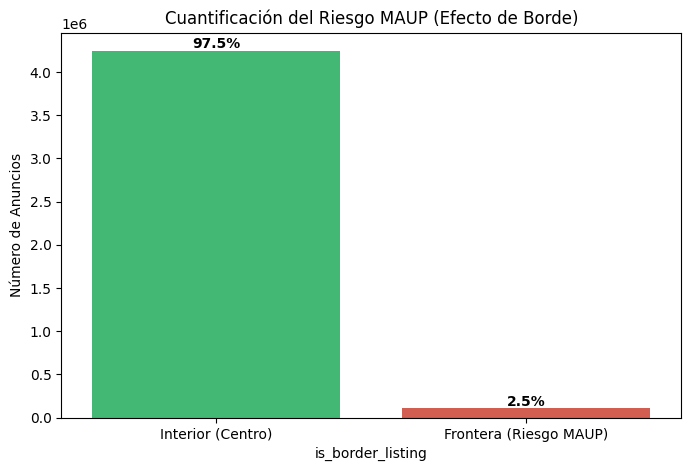

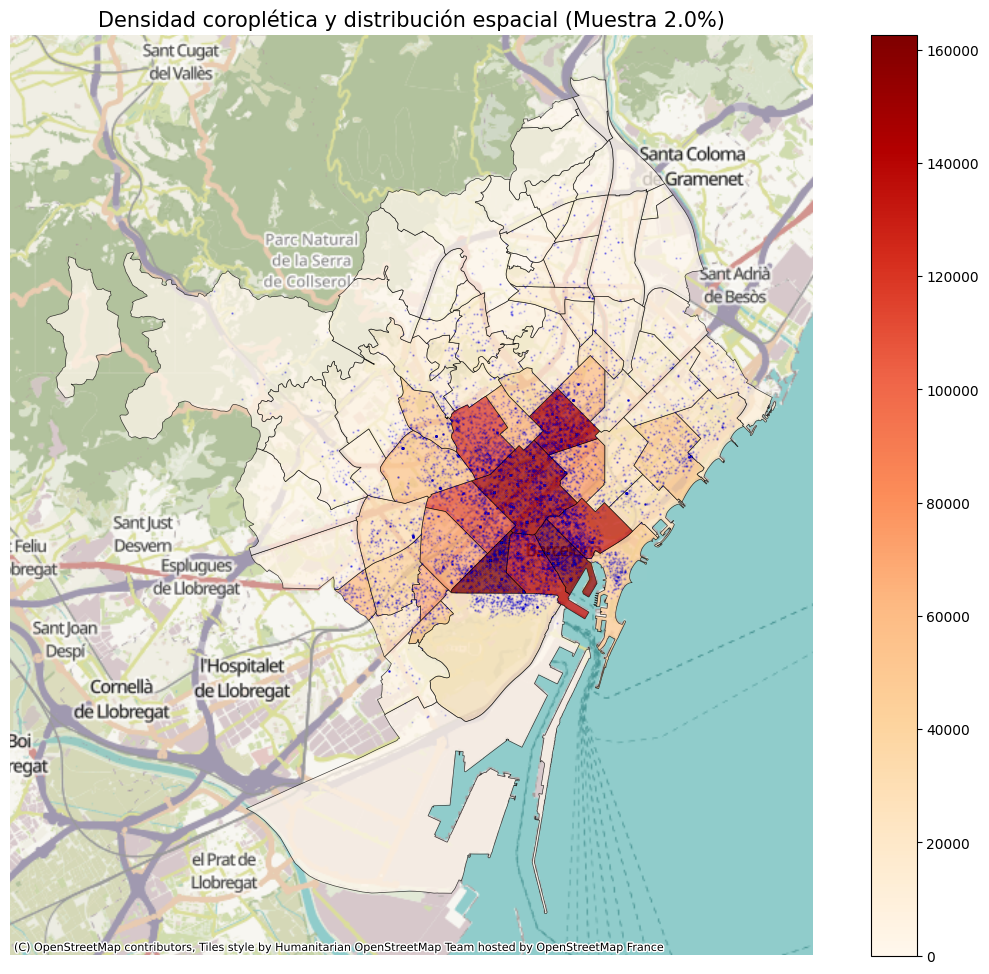


Dataset listo para EDA.


In [19]:
# Ejecución del pipeline

# 1. Calidad Tabular Base (Elimina errores lógicos y nulos críticos)
base_val = BaseQualityValidator()
df_dq_base = base_val.run_all(df_raw)

# 2. Calidad Temporal (Valida fechas y rangos)
temp_val = TemporalQualityValidator()
df_dq_temp = temp_val.run_all(df_dq_base)

# 3. Calidad Categórica (Estandariza textos y booleanos)
cat_val = CategoricalQualityValidator()
df_dq_cat = cat_val.run_all(df_dq_temp)

# 4. Calidad Espacial (Filtros GPS, Edge Effects y MAUP)
spatial_val = SpatialQualityValidator()
gdf_final_clean, gdf_barrios_densidad = spatial_val.run_all(df_dq_cat, df_barrios)

print("\nDataset listo para EDA.")

In [21]:
import os

# 1. Definir la ruta completa
ruta_guardado = "./data/airbnb_bcn_clean.parquet"

# 2. Extraer solo la ruta de las carpetas y crearlas si no existen
directorio = os.path.dirname(ruta_guardado)
os.makedirs(directorio, exist_ok=True)

# 3. Guardar el archivo
gdf_final_clean.to_parquet(ruta_guardado, index=False)

print(f"Datos guardados en: {ruta_guardado}")

Datos guardados en: ./data/processed/airbnb_bcn_clean.parquet
